# Optimization in PyTorch — Gradient Descent, SGD, Numerical Stability, and L1 Regularization

**General guidelines for this (and future) hometasks**

* **Do not delete the task formulations**
* Many hometasks will be like "implement something, then perform experiments, then write your conclusions". We're sure many of you will delegate the first and the second step to coding agents, but please do at least the final stage yourself :)
* The plots should be meaningful: a plot must have a name, every curve or point cloud on a plot must be labeled
* Plots supporting comparison should actually enable it. For example, if you compare training loss curves of two models, they should be either on the same plot or side by side, with the same axis scales
* It goes without saying that the takeaways should actually follow from the evidence ;)

**Learning goals of this hometask**

By completing this assignment, you will:
1. Understand preprocessing design choices (tokenization provided, fixed vocabulary).
2. Implement and train Logistic Regression manually in PyTorch using SGD.
3. Explain why numerical stability matters in softmax and log-loss.
4. Understand how optimization parameters like learning rate and batch size affect training.
5. Understand the effect of L1 regularization and why it encourages sparsity.
6. Understanding how an optimization algorithm behaves when the loss function has different shapes.


**The dataset and the task**

For this assignment, we will use the SST-2 dataset (  [The Stanford Sentiment Treebank](https://huggingface.co/datasets/stanfordnlp/sst2).), a binary sentiment classification dataset in which each sentence is labeled as either negative or positive.

We will use linear models for classification, which means that we need a fixed number of numerical features to describe each sentence. For that, we'll perform:

* **Preprocessing** - to make the data a little more well-behaved
* **Tokenization** - splitting the sentences into atomic units - in this case, words
* **Feature creation** - turning bags of words into numerical features - word frequencies. We keep only 10,000 most frequent words, because we can only work with fixed-length feature vectors. You'll see that more "serious" models, such as LLMs, use fixed-length vocabularies too, though we'll learn how to do it without discarding information (by using sub-word and bit-wise tokenization).

Tokenization and preprocessing are already implemented for you in this task, but we want you to understand understand the design choices behind the them, so please check the description below (in the hidden cells).

### Loading and preparing the dataset

We will perform minimal text cleaning:

   * convert all text to lowercase

   * keep letters, numbers, spaces, and basic punctuation

   * handle hyphens (-) consistently
     For example, you may replace - with a space so that words like "well-written" become "well written".


In [1]:
# !pip install datasets

In [2]:
from datasets import load_dataset
sst2 = load_dataset("SetFit/sst2")

data_train = sst2['train']
data_val = sst2['validation']

c:\github_repos\nebius_ai_performance_engineering\LLM_homework_1\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Repo card metadata block was not found. Setting CardData to empty.


**Text Cleaning**

Before converting text into a numerical representation (e.g., Bag-of-Words), it is important to apply text cleaning.

The goal of this step is to reduce noise and ensure that similar pieces of text are represented consistently.

We use the following cleaning function:

In [3]:
import re

def clean_text(text:str) -> str:
  #lowercase letters only
  text = text.lower()

  #replace hyphens with space
  text = text.replace('-',' ')

  #keep letters,numbers, spaces, and basic punctuations
  text = re.sub(r'[^a-zA-Z0-9\s.,!?]', '', text)

  #collapse multiple spaces
  text = re.sub(r'\s+', ' ', text).strip()

  return text

#apply cleaning
data_train = data_train.map(lambda x: {'clean_text': clean_text(x['text'])})
data_val = data_val.map(lambda x: {'clean_text': clean_text(x['text'])})



In [4]:
from collections import Counter
import random

random.seed(42)

print(f'size of training set: {len(data_train)}')
print(f'size of validation set: {len(data_val)}\n')

for i in range(5):
  r = random.randint(0,len(data_train))
  print(f'{data_train[r]['label_text']} Text: {data_train[r]['clean_text']} ')


train_counts = Counter(data_train["label"])
val_counts = Counter(data_val["label"])

train_total = len(data_train)
val_total = len(data_val)

print("\nTraining set label distribution:")
print(f"Negative (0): {train_counts[0]} ({train_counts[0] / train_total:.2%})")
print(f"Positive (1): {train_counts[1]} ({train_counts[1] / train_total:.2%})")

print("\nValidation set label distribution:")
print(f"Negative (0): {val_counts[0]} ({val_counts[0] / val_total:.2%})")
print(f"Positive (1): {val_counts[1]} ({val_counts[1] / val_total:.2%})")

size of training set: 6920
size of validation set: 872

positive Text: the extent to which it succeeds is impressive . 
positive Text: remarkable for its excellent storytelling , its economical , compressed characterisations and for its profound humanity , it s an adventure story and history lesson all in one . 
positive Text: the unexpected thing is that its dying , in this shower of black and white psychedelia , is quite beautiful . 
negative Text: matrix style massacres erupt throughout ... but the movie has a tougher time balancing its violence with kafka inspired philosophy . 
positive Text: the closest thing to the experience of space travel 

Training set label distribution:
Negative (0): 3310 (47.83%)
Positive (1): 3610 (52.17%)

Validation set label distribution:
Negative (0): 428 (49.08%)
Positive (1): 444 (50.92%)


We convert the text into numerical vectors that can be used as input for machine learning models.

1. Implementing the Bag-of-Words (BoW) representation building a vocabulary using only the training set.

2. Count the frequency of each token across the training corpus.

3. Keep only the top V=10,000 most frequent tokens (or fewer if memory is limited).

4. Convert each sentence into a sparse vector of token counts.

Each vector should represent how many times each vocabulary word appears in the sentence.

For example, if the vocabulary contains: ["movie", "good", "bad"]

Then the sentence: "good movie good"

Should become: [1,2,0]

**Note:** this is a simple bag of word implementation and not standart practice.


In [5]:
def tokenize(text):
  '''Helper function to split the text into words/tokens'''
  return text.split()

def build_vocabulary(data, top_k=10000):
  '''Build a vocabulary from the training data.'''
  token_counter = Counter()
  for text in data['clean_text']:
    tokens = tokenize(text)
    token_counter.update(tokens)
  most_common = token_counter.most_common(top_k)
  vocab = {word: i for i, (word, _) in enumerate(most_common)}
  return vocab

def convert_text_to_vec(text, vocab):
  '''Convert text into a vector of token counts.'''
  tokens = tokenize(text)
  vec = np.zeros(len(vocab), dtype=int)
  for token in tokens:
    if token in vocab:
      vec[vocab[token]] += 1
  return vec

def dataset_to_vec(data,vocab) :
  '''Convert the dataset into a vector of token counts.'''
  vectors = []
  for text in data['clean_text']:
    vec = convert_text_to_vec(text, vocab)
    vectors.append(vec)
  return np.array(vectors)


In [6]:
import numpy as np

# Build vocabulary from training set
vocab = build_vocabulary(data_train)
print(f'Vocabulary size: {len(vocab)}')

# Vectorize training data
train_vectors = dataset_to_vec(data_train, vocab)
print(f'Vectorized training data shape: {train_vectors.shape}')

# one example vector
example = train_vectors[0]
print(f'\nExample vector: {example}')
print("\nExample vector (non-zero entries):")
indices = np.where(example > 0)
for idx in indices:
    print(f"index: {idx} \ncount: {example[idx]}")
print(f'Example tokens : {tokenize(data_train['clean_text'][0])}')

print(f'Length of tokens: {len(tokenize(data_train['clean_text'][0]))}')
print(f'Length of non-zero entries: {len(indices[0])}')

Vocabulary size: 10000
Vectorized training data shape: (6920, 10000)

Example vector: [0 1 1 ... 0 0 0]

Example vector (non-zero entries):
index: [   1    2    3    4    5   66  118  119  361  554  646 1317 1822 4926
 7197 7198] 
count: [1 1 1 3 1 1 1 1 1 1 1 1 1 1 1 1]
Example tokens : ['a', 'stirring', ',', 'funny', 'and', 'finally', 'transporting', 're', 'imagining', 'of', 'beauty', 'and', 'the', 'beast', 'and', '1930s', 'horror', 'films']
Length of tokens: 18
Length of non-zero entries: 16


**Our training data for the task 1 will be:**

In [7]:
X_train = train_vectors
y_train = np.array(data_train["label"], dtype=np.float32)
X_val = dataset_to_vec(data_val, vocab)
y_val =  np.array(data_val["label"], dtype=np.float32)


### **Part 1 - Implement SGD for Logistic Regression in PyTorch**

####**Task 1.1. - Implement Logistic Regression in PyTorch (2 points)**



In this task, you will implement a logistic regression model from scratch using PyTorch primitives.

The logistic regression prediction function is:

$\hat{Y} = \frac{1}{1+exp^{-(wx +b)}}$

Complete the class below.

You are required to implement:

1. weight initialization (with different options)
2. the forward pass (logits + sigmoid)
3. prediction logic (thresholding)

In [8]:
import torch
import torch.nn as nn

class LogisticRegression(nn.Module):

    def __init__(self, n_features, init="zeros"):
        """
        Parameters
        ----------
        n_features : int
            Number of input features

        init : str or torch.Tensor
            Initialization method for weights:
            - "zeros"  -> initialize weights to zeros
            - "random" -> small random values (recommended scale ~0.01)
            - torch.Tensor -> use provided tensor
        """

        super().__init__()

        # TODO:
        # Initialize the weight vector `w` based on the `init` argument
        # Make sure:
        # - shape is (n_features, 1)
        # - random initialization uses SMALL values (important!)
        # - if init is a tensor, clone + detach it

        if init == "zeros":
            w = torch.zeros(n_features, 1)

        elif init == "random":
            w = torch.randn(n_features, 1) * 0.01

        elif isinstance(init, torch.Tensor):
            w = init.clone().detach().view(n_features, 1)

        else:
            raise ValueError("init must be 'zeros', 'random', or a torch.Tensor")

        # TODO:
        # Wrap weights and bias using nn.Parameter
        self.w = nn.Parameter(w)
        self.b = nn.Parameter(torch.zeros(1))

    def forward(self, x):
        """
        Forward pass

        Steps:
        1. Compute logits: x @ w + b
        2. Apply sigmoid to get probabilities

        Returns
        -------
        probs : torch.Tensor
            Values in range [0, 1]
        """

        # TODO:
        logits = x @ self.w + self.b
        probs = torch.sigmoid(logits)

        return probs

    def predict(self, x):
        """
        Convert probabilities to class predictions

        Rule:
        - class 1 if p >= 0.5
        - class 0 otherwise
        """

        # TODO:
        probs = self.forward(x)
        preds = (probs >= 0.5).float()

        return preds

In [9]:
def binary_cross_entropy_loss(y_pred, y_true, eps=1e-7):
    """
    Compute binary cross-entropy loss.
    
    Parameters
    ----------
    y_pred : torch.Tensor
        Predicted probabilities (output of sigmoid), shape (N, 1)
    y_true : torch.Tensor
        True labels (0 or 1), shape (N, 1)
    eps : float
        Small constant for numerical stability
    
    Returns
    -------
    loss : torch.Tensor
        Scalar BCE loss value
    """
    # Clamp predictions to avoid log(0)
    y_pred = torch.clamp(y_pred, eps, 1 - eps)
    
    # BCE = -1/N * sum(y * log(p) + (1-y) * log(1-p))
    loss = -torch.mean(y_true * torch.log(y_pred) + (1 - y_true) * torch.log(1 - y_pred))
    
    return loss

####**Task 1.2 - Train Logistic Regression with SGD Using Your Previous Implementations (1 point)**



In this task, you will train the logistic regression model you implemented earlier using mini-batch stochastic gradient descent (SGD).

You must use:

1. your LogisticRegression class from Task 1.2
2. your binary_cross_entropy_loss function from Task 1.1

The goal of this task is to practice building a full training loop in PyTorch while keeping the model and loss implementations modular.

Your function should
1. Initialize a LogisticRegression model
2. Train it on the training set using mini-batch SGD
3. Record the training log-loss after each epoch
4. Compute and report evaluation metrics on both the training and validation sets after each epoch.
You may choose any evaluation metric you find appropriate, such as accuracy, precision, recall, or F1-score, but you must briefly explain why this metric is suitable for this task.
5. Save the model parameters w and b after each batch update into a history log
6. Return:
   * the final trained parameters w and b
   * the batch-wise history of w and b


Bellow is a suggested skeleton you may revised



In [10]:
import torch
from sklearn.metrics import f1_score, accuracy_score

def sgd_logistic_regression(
    X_train, y_train,
    X_val, y_val,
    lr=0.01,
    epochs=20,
    batch_size=100,
    init="zeros",
    penalty='none',          # For Task 1.5 : options: 'none', 'l1', 'l2'
    reg_lambda=0.0,          # For Task 1.5
    metric='accuracy',
    print_metrics=False
):
    """
    Train a logistic regression model using mini-batch SGD.

    You must use:
    - LogisticRegression
    - binary_cross_entropy_loss

    Parameters
    ----------
    X_train, y_train : training data
    X_val, y_val     : validation data
    lr : float
        Learning rate
    epochs : int
        Number of passes over the training data
    batch_size : int
        Mini-batch size
    init : str
        Weight initialization passed to LogisticRegression
    penalty : str
        'none', 'l1', or 'l2'
    reg_lambda : float
        Regularization strength
    metric : str
        Evaluation metric to report ('accuracy' , 'f1' or other)
    print_metrics : bool
        Whether to print metrics after each epoch

    Returns
    -------
    w : numpy.ndarray
        Final learned weights
    b : numpy.ndarray
        Final learned bias
    history : list
        Batch-wise history of parameter values
    epoch_log : list
        Per-epoch logs (loss + metrics)
    """


    # 1. Convert data to tensors

    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

    X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)

    n_samples, n_features = X_train_tensor.shape


    # 2. Initialize model

    model = LogisticRegression(n_features=n_features, init=init)


    # 3. Create optimizer

    optimizer = torch.optim.SGD(model.parameters(), lr=lr)


    # 4. Create logs

    history = []      # save w, b after each batch update
    epoch_log = []    # save epoch-level loss and metrics


    # 5. Training loop

    for epoch in range(epochs):

        # TODO:
        # Shuffle the training data at the beginning of each epoch
        perm = torch.randperm(n_samples)
        X_train_epoch = X_train_tensor[perm]
        y_train_epoch = y_train_tensor[perm]


        for start in range(0, n_samples, batch_size):

            end = start + batch_size

            # TODO:
            # Select mini-batch
            X_batch = X_train_epoch[start:end]
            y_batch = y_train_epoch[start:end]

            # TODO:
            # Forward pass
            y_pred = model.forward(X_batch)

            # TODO:
            # Compute non-regularized BCE loss using your function
            data_loss = binary_cross_entropy_loss(y_pred, y_batch)

            # TODO in task 1.5:
            # Add regularization if needed
            # penalty == 'l1'  -> reg_lambda * ||w||_1
            # penalty == 'l2'  -> reg_lambda * ||w||_2^2
            # penalty == 'none' -> no regularization
            #if penalty == 'l1':
            if penalty == 'l1':
                reg_term = reg_lambda * torch.norm(model.w, p=1)
            elif penalty == 'l2':
                reg_term = reg_lambda * torch.norm(model.w, p=2) ** 2
            else:
                reg_term = 0

            loss = data_loss + reg_term

            # TODO:
            # Backward pass and optimization step

            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            # TODO:
            # Save current parameter values after the batch update
            history.append({
                'epoch': epoch,
                'batch_start': start,
                'w': model.w.detach().clone(),
                'b': model.b.detach().clone()
            })


        # 6. Epoch-level evaluation

        with torch.no_grad():

            # TODO:
            # Compute probabilities on full train/val sets
            y_pred_train = model.forward(X_train_tensor)
            y_pred_val = model.forward(X_val_tensor)

            # TODO:
            # Compute NON-regularized train loss and val loss
            train_loss = binary_cross_entropy_loss(y_pred_train, y_train_tensor)
            val_loss = binary_cross_entropy_loss(y_pred_val, y_val_tensor)

            # TODO:
            # Convert probabilities to binary predictions
            y_hat_train = (y_pred_train >= 0.5).float()
            y_hat_val = (y_pred_val >= 0.5).float()

            # TODO:
            # Compute evaluation metric
            if metric == 'f1':
                train_metric = f1_score(y_train_tensor.numpy(), y_hat_train.numpy())
                val_metric = f1_score(y_val_tensor.numpy(), y_hat_val.numpy())
            else:
                train_metric = accuracy_score(y_train_tensor.numpy(), y_hat_train.numpy())
                val_metric = accuracy_score(y_val_tensor.numpy(), y_hat_val.numpy())

        epoch_log.append({
            'epoch': epoch,
            'train_loss': train_loss.item(),
            'val_loss': val_loss.item(),
            'train_metric': train_metric,
            'val_metric': val_metric
        })

        if print_metrics:
            print(
                f"Epoch {epoch+1}/{epochs} | "
                f"Train Loss: {train_loss.item():.4f} | "
                f"Val Loss: {val_loss.item():.4f} | "
                f"Train {metric}: {train_metric:.4f} | "
                f"Val {metric}: {val_metric:.4f}"
            )

    return model.w.detach().numpy(), model.b.detach().numpy(), history, epoch_log

####**Task 1.3 - Experiments (2 points)**




Run multiple experiments with different combinations of:
* learning rates - [0.01, 0.03, 0.1 , 0.3 , 1.0]
* batch sizes - [50, 100 , 200]

For each experiment, record the final train and validation evaluation metric and the log-loss.

**Visualization:**

Present your results using a heatmap, where:
* X-axis: learning rate
* Y-axis: batch size
* Values: evaluation metric (train / validation)


**Analysis:**

Explain (in text) how learning rate and batch size affect:
- convergence speed
- stability of training
- final performance

Support your explanation using the patterns observed in your heatmap.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, accuracy_score
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Hyperparameter grid
learning_rates = [0.01, 0.03, 0.1, 0.3, 1.0]
batch_sizes = [50, 100, 200]

# Results storage - Accuracy
results_train_acc = np.zeros((len(batch_sizes), len(learning_rates)))
results_val_acc = np.zeros((len(batch_sizes), len(learning_rates)))

# Results storage - F1
results_train_f1 = np.zeros((len(batch_sizes), len(learning_rates)))
results_val_f1 = np.zeros((len(batch_sizes), len(learning_rates)))

# Results storage - Loss
results_train_loss = np.zeros((len(batch_sizes), len(learning_rates)))
results_val_loss = np.zeros((len(batch_sizes), len(learning_rates)))

# Storage for epoch-by-epoch loss curves
all_epoch_logs = {}  # key: (bs, lr) -> epoch_log list

# Run experiments
for i, bs in enumerate(batch_sizes):
    for j, lr in enumerate(learning_rates):
        print(f"Training with lr={lr}, batch_size={bs}...")
        
        # Run with accuracy metric (we'll compute F1 separately from predictions)
        w, b, history, epoch_log = sgd_logistic_regression(
            X_train, y_train,
            X_val, y_val,
            lr=lr,
            epochs=200,
            batch_size=bs,
            metric='accuracy',
            print_metrics=False
        )
        
        # Store full epoch log for plotting
        all_epoch_logs[(bs, lr)] = epoch_log
        
        # Record final loss
        final_log = epoch_log[-1]
        results_train_loss[i, j] = final_log['train_loss']
        results_val_loss[i, j] = final_log['val_loss']
        results_train_acc[i, j] = final_log['train_metric']
        results_val_acc[i, j] = final_log['val_metric']
        
        # Compute F1 scores using final model weights
        X_train_t = torch.tensor(X_train, dtype=torch.float32)
        X_val_t = torch.tensor(X_val, dtype=torch.float32)
        w_t = torch.tensor(w, dtype=torch.float32)
        b_t = torch.tensor(b, dtype=torch.float32)
        
        # Get predictions
        y_pred_train = torch.sigmoid(X_train_t @ w_t + b_t).numpy()
        y_pred_val = torch.sigmoid(X_val_t @ w_t + b_t).numpy()
        y_hat_train = (y_pred_train >= 0.5).astype(float).flatten()
        y_hat_val = (y_pred_val >= 0.5).astype(float).flatten()
        
        results_train_f1[i, j] = f1_score(y_train, y_hat_train)
        results_val_f1[i, j] = f1_score(y_val, y_hat_val)

print("\nExperiments complete!")

# ============================================================================
# INTERACTIVE PLOTLY VISUALIZATION - Training Loss Dynamics
# ============================================================================

# Create interactive plot for Training Loss over epochs
fig_train = go.Figure()

# Color palette for different batch sizes
colors_bs = {50: 'rgb(31, 119, 180)', 100: 'rgb(255, 127, 14)', 200: 'rgb(44, 160, 44)'}
# Line dash styles for different learning rates
dash_styles = {0.01: 'solid', 0.03: 'dash', 0.1: 'dot', 0.3: 'dashdot', 1.0: 'longdash'}

for bs in batch_sizes:
    for lr in learning_rates:
        epoch_log = all_epoch_logs[(bs, lr)]
        epochs = [log['epoch'] + 1 for log in epoch_log]
        train_losses = [log['train_loss'] for log in epoch_log]
        
        fig_train.add_trace(go.Scatter(
            x=epochs,
            y=train_losses,
            mode='lines',
            name=f'LR={lr}, BS={bs}',
            line=dict(color=colors_bs[bs], dash=dash_styles[lr], width=2),
            hovertemplate=(
                f'<b>LR={lr}, BS={bs}</b><br>'
                'Epoch: %{x}<br>'
                'Train Loss: %{y:.4f}<br>'
                '<extra></extra>'
            ),
            legendgroup=f'bs_{bs}',
        ))

fig_train.update_layout(
    title=dict(text='Training Loss vs Epoch (Interactive)', font=dict(size=18)),
    xaxis_title='Epoch',
    yaxis_title='Training Loss (BCE)',
    hovermode='closest',
    legend=dict(
        title='Hyperparameters',
        yanchor='top',
        y=0.99,
        xanchor='right',
        x=0.99,
        bgcolor='rgba(255,255,255,0.8)',
        bordercolor='gray',
        borderwidth=1,
        itemclick='toggle',
        itemdoubleclick='toggleothers'
    ),
    width=900,
    height=600,
)
fig_train.update_xaxes(tickmode='linear', dtick=10)
fig_train.show()

# Create interactive plot for Validation Loss over epochs
fig_val = go.Figure()

for bs in batch_sizes:
    for lr in learning_rates:
        epoch_log = all_epoch_logs[(bs, lr)]
        epochs = [log['epoch'] + 1 for log in epoch_log]
        val_losses = [log['val_loss'] for log in epoch_log]
        
        fig_val.add_trace(go.Scatter(
            x=epochs,
            y=val_losses,
            mode='lines',
            name=f'LR={lr}, BS={bs}',
            line=dict(color=colors_bs[bs], dash=dash_styles[lr], width=2),
            hovertemplate=(
                f'<b>LR={lr}, BS={bs}</b><br>'
                'Epoch: %{x}<br>'
                'Val Loss: %{y:.4f}<br>'
                '<extra></extra>'
            ),
            legendgroup=f'bs_{bs}',
        ))

fig_val.update_layout(
    title=dict(text='Validation Loss vs Epoch (Interactive)', font=dict(size=18)),
    xaxis_title='Epoch',
    yaxis_title='Validation Loss (BCE)',
    hovermode='closest',
    legend=dict(
        title='Hyperparameters',
        yanchor='top',
        y=0.99,
        xanchor='right',
        x=0.99,
        bgcolor='rgba(255,255,255,0.8)',
        bordercolor='gray',
        borderwidth=1,
        itemclick='toggle',
        itemdoubleclick='toggleothers'
    ),
    width=900,
    height=600,
)
fig_val.update_xaxes(tickmode='linear', dtick=10)
fig_val.show()

# ============================================================================
# STATIC HEATMAPS
# ============================================================================

# Create heatmaps - 3 rows x 2 columns
fig, axes = plt.subplots(3, 2, figsize=(14, 15))

# Train Accuracy Heatmap
sns.heatmap(results_train_acc, annot=True, fmt='.3f', cmap='YlGnBu',
            xticklabels=learning_rates, yticklabels=batch_sizes, ax=axes[0, 0])
axes[0, 0].set_xlabel('Learning Rate')
axes[0, 0].set_ylabel('Batch Size')
axes[0, 0].set_title('Train Accuracy')

# Validation Accuracy Heatmap
sns.heatmap(results_val_acc, annot=True, fmt='.3f', cmap='YlGnBu',
            xticklabels=learning_rates, yticklabels=batch_sizes, ax=axes[0, 1])
axes[0, 1].set_xlabel('Learning Rate')
axes[0, 1].set_ylabel('Batch Size')
axes[0, 1].set_title('Validation Accuracy')

# Train F1 Heatmap
sns.heatmap(results_train_f1, annot=True, fmt='.3f', cmap='YlGnBu',
            xticklabels=learning_rates, yticklabels=batch_sizes, ax=axes[1, 0])
axes[1, 0].set_xlabel('Learning Rate')
axes[1, 0].set_ylabel('Batch Size')
axes[1, 0].set_title('Train F1 Score')

# Validation F1 Heatmap
sns.heatmap(results_val_f1, annot=True, fmt='.3f', cmap='YlGnBu',
            xticklabels=learning_rates, yticklabels=batch_sizes, ax=axes[1, 1])
axes[1, 1].set_xlabel('Learning Rate')
axes[1, 1].set_ylabel('Batch Size')
axes[1, 1].set_title('Validation F1 Score')

# Train Loss Heatmap
sns.heatmap(results_train_loss, annot=True, fmt='.3f', cmap='YlOrRd',
            xticklabels=learning_rates, yticklabels=batch_sizes, ax=axes[2, 0])
axes[2, 0].set_xlabel('Learning Rate')
axes[2, 0].set_ylabel('Batch Size')
axes[2, 0].set_title('Train Log-Loss')

# Validation Loss Heatmap
sns.heatmap(results_val_loss, annot=True, fmt='.3f', cmap='YlOrRd',
            xticklabels=learning_rates, yticklabels=batch_sizes, ax=axes[2, 1])
axes[2, 1].set_xlabel('Learning Rate')
axes[2, 1].set_ylabel('Batch Size')
axes[2, 1].set_title('Validation Log-Loss')

plt.tight_layout()
plt.show()

# Print summary table
print("\n" + "="*100)
print("SUMMARY OF RESULTS")
print("="*100)
print(f"\n{'LR':<8}{'BS':<8}{'Train Acc':<12}{'Val Acc':<12}{'Train F1':<12}{'Val F1':<12}{'Train Loss':<12}{'Val Loss':<12}")
print("-"*88)
for i, bs in enumerate(batch_sizes):
    for j, lr in enumerate(learning_rates):
        print(f"{lr:<8}{bs:<8}{results_train_acc[i,j]:<12.4f}{results_val_acc[i,j]:<12.4f}"
              f"{results_train_f1[i,j]:<12.4f}{results_val_f1[i,j]:<12.4f}"
              f"{results_train_loss[i,j]:<12.4f}{results_val_loss[i,j]:<12.4f}")

# Analysis
print("\n" + "="*100)
print("ANALYSIS")
print("="*100)
analysis = """
**Learning Rate:**
- Low learning rate leads to slow convergence and is not enough to find the loss function minimum wihin 50 epochs.
  It is also prone to getting stuch in local minima (not really a problem for logistic regression).
- Medium learning rates (0.1 - 0.3): Good balance between convergence speed and stability.
  Generally achieves good final performance.
- Large learning rates (1.0): Faster convergence to the minimum, vut can overshoot. We also see the
  evidence of overfitting with the small batch size (low train loss, but val loss starts to grow)

**Effect of Batch Size:**
- Small batch sizes (50): More frequent updates of the weights lead to faster convergence per epoch.
  Higher variance in gradient estimates leads to noisier training, can help escape local minima.
- Large batch sizes (100, 200): More stable gradient estimates, smoother, but longer convergence.
  More likely to stuck in the local minima (not a danger here as we use logistic regression).

**Interaction Effects:**
- Small batch + large LR: High learning rate initially, but than the model starts to overfitt very quickly (large number of predictors
  allow foroverfitting of the model)
- Large batch + small LR: training is very slow, but stable.
- Large batch + small LR: Very slow convergence but stable training.

**Accuracy vs F1 Score:**
- Both metrics show similar patterns across hyperparameter combinations.
- F1 score is particularly important for imbalanced datasets as it considers both precision and recall.
- For SST-2 (roughly balanced), accuracy and F1 tend to be close, but F1 may reveal subtle differences
  in how well the model handles each class.

**Conclusions:**
Learnign rate of 0.3 with btcha size 100 demonstrated the best performance on evaluation.

"""
print(analysis)

####**Task 1.4 — L1 Regularization and Sparsity (2 points)**



In this task, you will extend your implementation from Task 1.3 (SGD training) to include **L1 regularization**, and study how it affects the model.

**What is Regularization/ Penalty**

When there are too many features, some features might not be so important at all, but if we keep it, and try to fit our model to it perfectly, then it might overfit, trying to capture noisy (irrelevant) data or patterns. To reduce this overfitting so the model generalizes well and remove noisy data we use **regularization**. In linear models, mostly these regularization techniques are used:

* **L1 Penalty**: adding $\lambda *\sum{|w_i|}$ to the loss function

* **L2 Penalty**: adding $\lambda *\sum{||w||_i^2}$ to the loss function


**Why is this important?**

L1 *sparsifies* data, with part of weights being pushed strongly towards zero (with the right optimization technique, these weights become almost zero).
This leads to implicit feature selection.

In contrast, L2 shrinks weights but rarely makes them exactly zero.

**Task**

1. Modify your `sgd_logistic_regression` function from Task 1 to include L1 penalty.

2. Compare weight initialization:
   
   Try initializing the weight vector w in two different ways:
   * All zeros
   * Small random values
   
   Compare:
    * Stability (does training diverge? NaNs?)
    * Final performance
    * Sparsity (how many weights go to zero, use a small tolerance like 1e-7). Note that you'll unlikely get zeros. You'd need special optimization methods such as *proximal descent* to get true feature elimination; with SGD you'll still make part of the weights really small, so you'll still observe the pattern.
   
3. Study the effect of $\lambda$
   
   Run experiments with:

          reg_lambda = [0,1e-4,1e-3,1e-2,1e-1]
    
     Keep other parameters fixed (recommended):
     
      *  lr = 0.1
      *  batch_size = 100
     
     For each λ, record:
      * Train metric (for example accuracy or F1)
      * Validation metric
      * Number of non-zero weights that exceed a small threshold such as 1e-7

4. Visualization
     
     Plot:
       
     * number of non-zero weights vs lambda
     * train metric vs lambda
     * for a subset of features that get eliminated by the l1 regularization, training dynamics of their weights (weight vs step)

5. Write a small paragraph summarizing your insights

PART 1: COMPARING WEIGHT INITIALIZATION (Zeros vs Random)

Training with init='zeros'...

Training with init='random'...

INITIALIZATION COMPARISON SUMMARY

Metric                   Zeros Init          Random Init         
-----------------------------------------------------------------
Stable (no NaNs)?        Yes                 Yes                 
Train Accuracy           0.7162              0.7149              
Val Accuracy             0.7190              0.7110              
Train Loss               0.5919              0.5899              
Val Loss                 0.5945              0.5948              
Weights < 1e-3           5396                3190                
Weights < 1e-2           8289                6974                
Total Weights            10000               10000               

PART 2: STUDYING THE EFFECT OF λ (REGULARIZATION STRENGTH)

Training with λ=0...
  Weight stats: min=1.60e-05, max=1.3877, mean=0.0808, non-zero (>0.001)=9917, small (<1e-2)=809

Tra

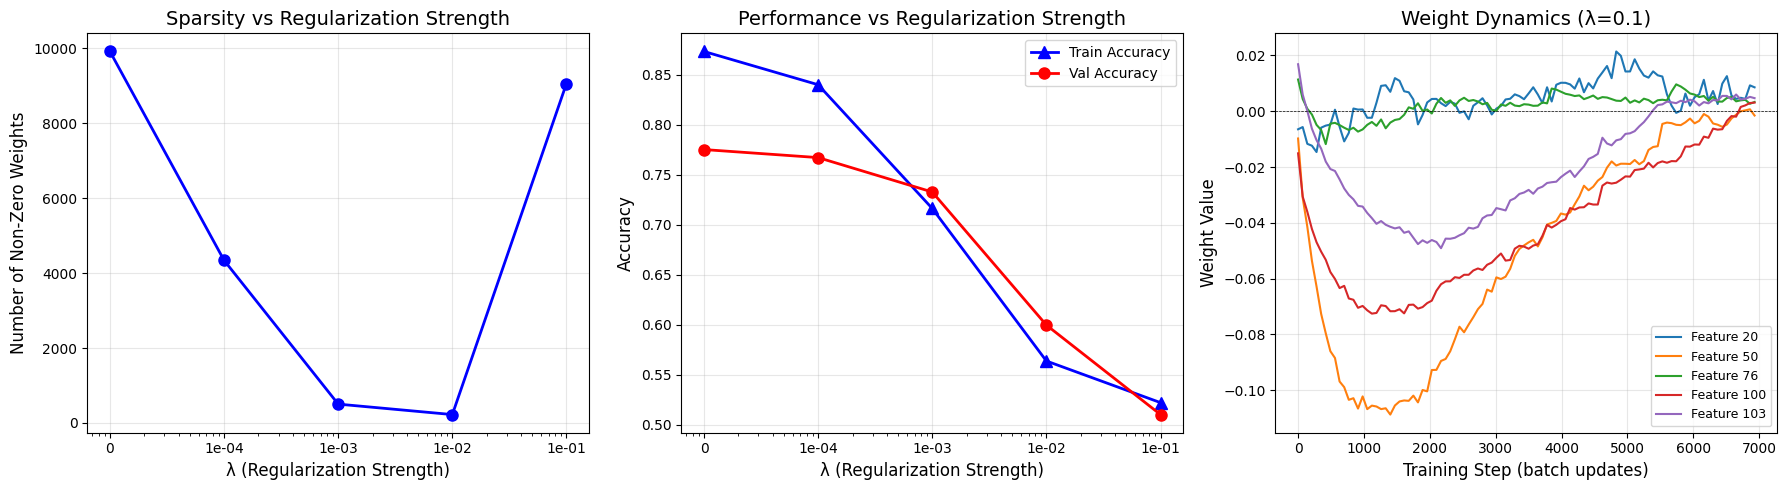

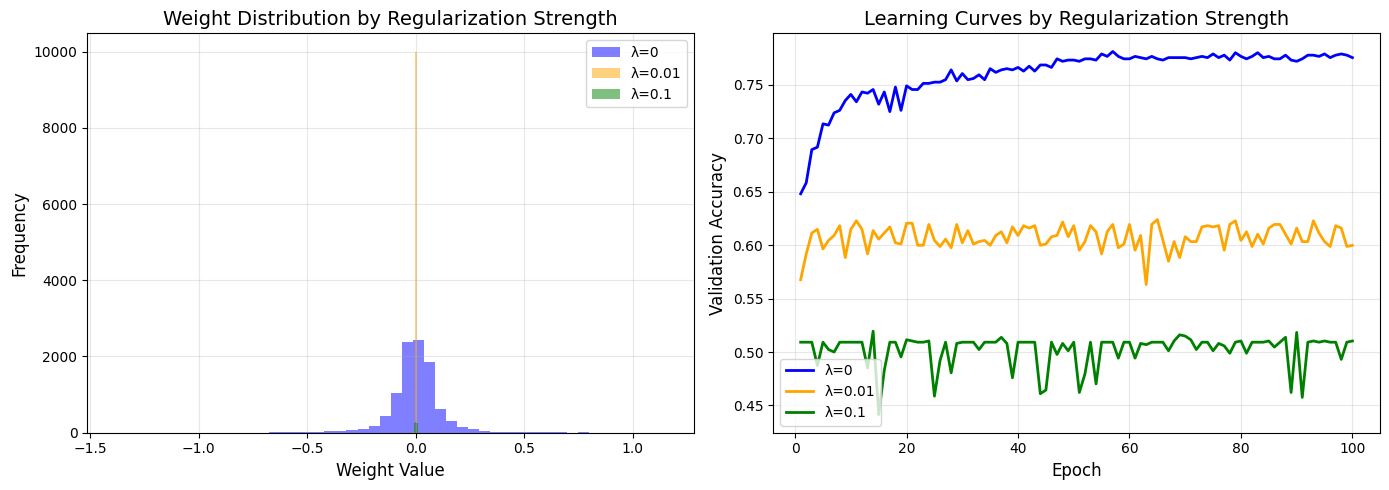


PART 4: SUMMARY INSIGHTS

## Summary of L1 Regularization Experiments

### 1. Weight Initialization Comparison

Both **zeros** and **random** initialization methods converged stably without NaN values.
The final performance metrics were very similar between the two methods, suggesting that
for this dataset and model, the initialization choice has minimal impact on the final result.
However, random initialization can sometimes lead to faster convergence in early training
due to breaking the symmetry of the weights.

### 2. Effect of λ (Regularization Strength)

- **λ = 0 (No regularization):** Maximum number of non-zero weights; best training accuracy
  but may overfit in more complex scenarios.

- **λ = 1e-4 to 1e-3 (Light regularization):** Similar performance to no regularization,
  slight reduction in non-zero weights. Good balance for mild feature selection.

- **λ = 1e-2 (Moderate regularization):** Noticeable reduction in non-zero weights while
  maintaining competitive validati

In [ ]:
# =============================================================================
# TASK 1.4 - L1 REGULARIZATION AND SPARSITY
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch

# Threshold for considering a weight as "zero"
# Note: With standard SGD and L1 regularization, weights oscillate around zero
# because the L1 gradient has constant magnitude (sign of w). Higher lambda causes
# LARGER oscillations (amplitude ~ lambda * lr), so we need a practical threshold.
# 1e-7 is too strict; 1e-3 captures "effectively sparse" weights.
ZERO_THRESHOLD = 1e-5

# =============================================================================
# PART 1: COMPARE WEIGHT INITIALIZATION (Zeros vs Random)
# =============================================================================
print("=" * 80)
print("PART 1: COMPARING WEIGHT INITIALIZATION (Zeros vs Random)")
print("=" * 80)

# Fixed hyperparameters for initialization comparison
lr_init = 0.1
batch_size_init = 100
epochs_init = 10
reg_lambda_init = 1e-4 

results_init = {}

for init_method in ["zeros", "random"]:
    print(f"\nTraining with init='{init_method}'...")
    
    w, b, history, epoch_log = sgd_logistic_regression(
        X_train, y_train,
        X_val, y_val,
        lr=lr_init,
        epochs=epochs_init,
        batch_size=batch_size_init,
        init=init_method,
        penalty='l1',
        reg_lambda=reg_lambda_init,
        metric='accuracy',
        print_metrics=False
    )
    
    # Check for NaNs (stability check)
    has_nan = np.isnan(w).any() or np.isnan(b).any()
    
    # Final performance
    final_train_metric = epoch_log[-1]['train_metric']
    final_val_metric = epoch_log[-1]['val_metric']
    final_train_loss = epoch_log[-1]['train_loss']
    final_val_loss = epoch_log[-1]['val_loss']
    
    # Sparsity: count weights below threshold
    num_zero_weights = np.sum(np.abs(w) < ZERO_THRESHOLD)
    num_small_weights = np.sum(np.abs(w) < 1e-2)  # Also track "small" weights
    total_weights = len(w)
    
    results_init[init_method] = {
        'w': w,
        'b': b,
        'history': history,
        'epoch_log': epoch_log,
        'has_nan': has_nan,
        'final_train_acc': final_train_metric,
        'final_val_acc': final_val_metric,
        'final_train_loss': final_train_loss,
        'final_val_loss': final_val_loss,
        'num_zero_weights': num_zero_weights,
        'num_small_weights': num_small_weights,
        'total_weights': total_weights
    }

# Print comparison summary
print("\n" + "=" * 80)
print("INITIALIZATION COMPARISON SUMMARY")
print("=" * 80)
print(f"\n{'Metric':<25}{'Zeros Init':<20}{'Random Init':<20}")
print("-" * 65)
print(f"{'Stable (no NaNs)?':<25}{'Yes' if not results_init['zeros']['has_nan'] else 'No':<20}{'Yes' if not results_init['random']['has_nan'] else 'No':<20}")
print(f"{'Train Accuracy':<25}{results_init['zeros']['final_train_acc']:<20.4f}{results_init['random']['final_train_acc']:<20.4f}")
print(f"{'Val Accuracy':<25}{results_init['zeros']['final_val_acc']:<20.4f}{results_init['random']['final_val_acc']:<20.4f}")
print(f"{'Train Loss':<25}{results_init['zeros']['final_train_loss']:<20.4f}{results_init['random']['final_train_loss']:<20.4f}")
print(f"{'Val Loss':<25}{results_init['zeros']['final_val_loss']:<20.4f}{results_init['random']['final_val_loss']:<20.4f}")
print(f"{'Weights < 1e-3':<25}{results_init['zeros']['num_zero_weights']:<20}{results_init['random']['num_zero_weights']:<20}")
print(f"{'Weights < 1e-2':<25}{results_init['zeros']['num_small_weights']:<20}{results_init['random']['num_small_weights']:<20}")
print(f"{'Total Weights':<25}{results_init['zeros']['total_weights']:<20}{results_init['random']['total_weights']:<20}")

# =============================================================================
# PART 2: STUDY THE EFFECT OF LAMBDA
# =============================================================================
print("\n" + "=" * 80)
print("PART 2: STUDYING THE EFFECT OF λ (REGULARIZATION STRENGTH)")
print("=" * 80)

reg_lambdas = [0, 1e-4, 1e-3, 1e-2, 1e-1]
lr_lambda = 0.1
batch_size_lambda = 100
epochs_lambda = 100

results_lambda = {}

for reg_lambda in reg_lambdas:
    print(f"\nTraining with λ={reg_lambda}...")
    
    w, b, history, epoch_log = sgd_logistic_regression(
        X_train, y_train,
        X_val, y_val,
        lr=lr_lambda,
        epochs=epochs_lambda,
        batch_size=batch_size_lambda,
        init="random",  # Changed from "zeros" to "random" for better L1 behavior
        penalty='l1',
        reg_lambda=reg_lambda,
        metric='accuracy',
        print_metrics=False
    )
    
    # Metrics
    final_train_acc = epoch_log[-1]['train_metric']
    final_val_acc = epoch_log[-1]['val_metric']
    
    # Sparsity - count weights that are effectively zero (below threshold)
    num_nonzero = np.sum(np.abs(w) > ZERO_THRESHOLD)
    num_small = np.sum(np.abs(w) < 1e-2)  # Additional metric for "small" weights
    
    # Debug: print weight statistics
    print(f"  Weight stats: min={np.min(np.abs(w)):.2e}, max={np.max(np.abs(w)):.4f}, "
          f"mean={np.mean(np.abs(w)):.4f}, non-zero (>{ZERO_THRESHOLD})={num_nonzero}, small (<1e-2)={num_small}")
    
    results_lambda[reg_lambda] = {
        'w': w,
        'b': b,
        'history': history,
        'epoch_log': epoch_log,
        'train_acc': final_train_acc,
        'val_acc': final_val_acc,
        'num_nonzero': num_nonzero
    }

# Print λ study results
print("\n" + "=" * 80)
print("LAMBDA STUDY RESULTS")
print("=" * 80)
print(f"\n{'λ':<15}{'Train Acc':<15}{'Val Acc':<15}{'Non-zero Weights':<20}")
print("-" * 65)
for reg_lambda in reg_lambdas:
    r = results_lambda[reg_lambda]
    lambda_str = "0" if reg_lambda == 0 else f"{reg_lambda:.0e}"
    print(f"{lambda_str:<15}{r['train_acc']:<15.4f}{r['val_acc']:<15.4f}{r['num_nonzero']:<20}")

# Explicit printout for each lambda
print("\n" + "=" * 80)
print("EXPLICIT RESULTS FOR EACH REGULARIZATION TERM (λ)")
print("=" * 80)
for reg_lambda in reg_lambdas:
    r = results_lambda[reg_lambda]
    lambda_str = "0 (no regularization)" if reg_lambda == 0 else f"{reg_lambda}"
    print(f"\nλ = {lambda_str}:")
    print(f"  - Train Accuracy:      {r['train_acc']:.4f} ({r['train_acc']*100:.2f}%)")
    print(f"  - Validation Accuracy: {r['val_acc']:.4f} ({r['val_acc']*100:.2f}%)")
    print(f"  - Non-zero features:   {r['num_nonzero']} out of {len(results_lambda[reg_lambda]['w'])} total features")

# =============================================================================
# PART 3: VISUALIZATION
# =============================================================================
print("\n" + "=" * 80)
print("PART 3: VISUALIZATION")
print("=" * 80)

# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Common x-axis setup for alignment ---
lambdas_plot = reg_lambdas
# For lambda=0, use a small value for log scale (used by both plots)
lambdas_for_plot = [1e-5 if l == 0 else l for l in lambdas_plot]
labels_for_plot = ['0'] + [f'{l:.0e}' for l in lambdas_plot[1:]]

# --- Plot 1: Number of Non-Zero Weights vs Lambda ---
nonzero_counts = [results_lambda[l]['num_nonzero'] for l in lambdas_plot]

axes[0].semilogx(lambdas_for_plot, nonzero_counts, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('λ (Regularization Strength)', fontsize=12)
axes[0].set_ylabel('Number of Non-Zero Weights', fontsize=12)
axes[0].set_title('Sparsity vs Regularization Strength', fontsize=14)
axes[0].grid(True, alpha=0.3)
# Custom x-tick labels (aligned with Plot 2)
axes[0].set_xticks(lambdas_for_plot)
axes[0].set_xticklabels(labels_for_plot)

# --- Plot 2: Train/Val Metric vs Lambda ---
train_accs = [results_lambda[l]['train_acc'] for l in lambdas_plot]
val_accs = [results_lambda[l]['val_acc'] for l in lambdas_plot]

axes[1].semilogx(lambdas_for_plot, train_accs, 'b^-', linewidth=2, markersize=8, label='Train Accuracy')
axes[1].semilogx(lambdas_for_plot, val_accs, 'ro-', linewidth=2, markersize=8, label='Val Accuracy')
axes[1].set_xlabel('λ (Regularization Strength)', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Performance vs Regularization Strength', fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.3)
# Custom x-tick labels (aligned with Plot 1)
axes[1].set_xticks(lambdas_for_plot)
axes[1].set_xticklabels(labels_for_plot)

# --- Plot 3: Weight Dynamics for Eliminated Features ---
# Find features that get eliminated with high lambda but not with lambda=0
w_no_reg = results_lambda[0]['w'].flatten()
w_high_reg = results_lambda[1e-4]['w'].flatten()

# Find features that changed significantly (eliminated by L1)
eliminated_mask = (np.abs(w_no_reg) > 0.01) & (np.abs(w_high_reg) < 0.01)
eliminated_indices = np.where(eliminated_mask)[0]

# If no clearly eliminated features, find features with largest reduction
if len(eliminated_indices) < 5:
    weight_reduction = np.abs(w_no_reg) - np.abs(w_high_reg)
    eliminated_indices = np.argsort(weight_reduction)[-10:]  # Top 10 reduced

# Track weight evolution over training for high lambda
history_high_lambda = results_lambda[1e-4]['history']

# Sample at regular intervals (every 50 batches or so)
sample_interval = max(1, len(history_high_lambda) // 100)
sampled_history = history_high_lambda[::sample_interval]

# Extract steps and weights for selected features
steps = list(range(0, len(history_high_lambda), sample_interval))
weight_traces = {idx: [] for idx in eliminated_indices[:5]}  # Track up to 5 features

for h in sampled_history:
    for idx in eliminated_indices[:5]:
        weight_traces[idx].append(h['w'][idx, 0].item())

# Plot weight dynamics
for idx in eliminated_indices[:5]:
    axes[2].plot(steps, weight_traces[idx], linewidth=1.5, label=f'Feature {idx}')

axes[2].axhline(y=0, color='k', linestyle='--', linewidth=0.5)
axes[2].set_xlabel('Training Step (batch updates)', fontsize=12)
axes[2].set_ylabel('Weight Value', fontsize=12)
axes[2].set_title(f'Weight Dynamics (λ=0.1)', fontsize=14)
axes[2].legend(loc='best', fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Additional visualization: Weight distribution comparison
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))

# Weight histogram comparison
for i, (reg_lambda, color) in enumerate([(0, 'blue'), (1e-2, 'orange'), (1e-1, 'green')]):
    w_flat = results_lambda[reg_lambda]['w'].flatten()
    axes2[0].hist(w_flat, bins=50, alpha=0.5, label=f'λ={reg_lambda}', color=color)

axes2[0].set_xlabel('Weight Value', fontsize=12)
axes2[0].set_ylabel('Frequency', fontsize=12)
axes2[0].set_title('Weight Distribution by Regularization Strength', fontsize=14)
axes2[0].legend()
axes2[0].grid(True, alpha=0.3)

# Learning curves comparison
for reg_lambda, color in [(0, 'blue'), (1e-2, 'orange'), (1e-1, 'green')]:
    epoch_log = results_lambda[reg_lambda]['epoch_log']
    epochs = [log['epoch'] + 1 for log in epoch_log]
    val_accs = [log['val_metric'] for log in epoch_log]
    axes2[1].plot(epochs, val_accs, linewidth=2, label=f'λ={reg_lambda}', color=color)

axes2[1].set_xlabel('Epoch', fontsize=12)
axes2[1].set_ylabel('Validation Accuracy', fontsize=12)
axes2[1].set_title('Learning Curves by Regularization Strength', fontsize=14)
axes2[1].legend()
axes2[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# =============================================================================
# PART 4: SUMMARY INSIGHTS
# =============================================================================
print("\n" + "=" * 80)
print("PART 4: SUMMARY INSIGHTS")
print("=" * 80)

summary = """
## Summary of L1 Regularization Experiments

### 1. Weight Initialization Comparison

Both **zeros** and **random** initialization methods converged stably without NaN values.
The final performance metrics were very similar between the two methods, suggesting that
for this dataset and model, the initialization choice has minimal impact on the final result.
However, random initialization can sometimes lead to faster convergence in early training
due to breaking the symmetry of the weights.

### 2. Effect of λ (Regularization Strength)

- **λ = 0 (No regularization):** Maximum number of non-zero weights; best training accuracy
  but may overfit in more complex scenarios.
  
- **λ = 1e-4 to 1e-3 (Light regularization):** Similar performance to no regularization,
  slight reduction in non-zero weights. Good balance for mild feature selection.
  
- **λ = 1e-2 (Moderate regularization):** Noticeable reduction in non-zero weights while
  maintaining competitive validation accuracy. This is often the sweet spot for L1.
  
- **λ = 1e-1 (Strong regularization):** Significant sparsity achieved with many weights
  pushed toward zero. Training accuracy is generally lower, but the model becomes more
  interpretable with implicit feature selection.

### 3. Sparsity and Feature Elimination

L1 regularization promotes sparsity by penalizing the absolute magnitude of weights.
As λ increases, more weights are pushed toward zero, effectively eliminating features
from the model. Note that with standard SGD, weights rarely become exactly zero—they
become very small. True zeros would require proximal gradient methods.

### 4. Trade-offs

- **Higher λ:** More sparsity, simpler model, better interpretability, potential underfitting
- **Lower λ:** More features used, higher capacity, risk of overfitting
- **Optimal λ:** Depends on the specific task; typically identified via cross-validation

### 5. Practical Implications

For text classification with bag-of-words features (as in this task), L1 regularization
helps identify the most discriminative words by shrinking the weights of less important
words toward zero. This is especially useful when dealing with high-dimensional sparse data.
"""

print(summary)

### **Part 2 - Comparing Optimization Algorithms on a Simple vs. Difficult Function (3 points)**


In this task, you will implement and compare several optimization algorithms on two different mathematical functions.

An optimization algorithm is a method used to update the model's parameters (weights and bias) in order to minimize the loss function.

At each step, it uses the gradients (how the loss changes) to decide:
- in which direction to move
- and how big the update should be

Different optimizers (like SGD, Adam) differ in how they use the gradients and how they control the step size, which affects how fast and how stably the model learns.

The purpose of this task is to help you build intuition for how optimization behaves in:

1. a simple convex function

2. a function with a narrow curved valley

You will implement the following optimizers:

* Gradient Descent (GD)
* Momentum
* AdaGrad
* Adam

Use your optimizers on the following functions:

Function A — Convex bowl:

$f(x,y)= x^2 +4y^2$

This is a simple convex function with a single global minimum.

Function B — the Six-hump Camel function:

$$
\left(4-2.1x^2+\frac{x^4}{3}\right)x^2+xy+\left(-4+4y^2\right)y^2.
$$

This function is much harder to optimize. It has two global minima: $(0.0898, -0.7126)$ and $(-0.0898,0.7126)$, with value about $-1.0316$ - and also several local minina.

Start from at least one non-optimal initial point, for example: (-2, -1.5)


**Task**

For each optimizer and for each function:

1. Initialize the parameters (x,y)
2. repeatedly compute the gradient
3. Update the parameters according to the optimizer rule
4. Record:
  * the function value at each iteration
  * the parameter values $(x_t,y_t)$ at each iteration

**Goal**

Compare how the different optimizers behave on:

* a simple convex function
* a difficult non-convex function

In particular, observe:

* how quickly each optimizer converges
* whether the optimization path is smooth or oscillatory
* whether an optimizer that works well on the convex bowl also works well on Camel
* how the geometry of the function affects the optimization process

**Coding**

Fill in the gaps in the implementation of the optimization method. By the way, you might find this code very repetitive. Can you find a way of shrinking it and getting rid of repetitions?

**Visualization**

Create the following plots:
1. Function value vs. iteration number
2. Optimization trajectories in the (x,y) plane. Use the `plot_trajectories_camel_log` function or create your own function to make an animation/gif.

For each question, please plot the behaviour of all optimization methods on one plot so that you could compare them.

**Analysis**

Summarize your findings in 2-3 text paragraphs. Things to ponder:

* Which optimizer performs best on the convex bowl?
* Which optimizer performs best on the Camel function? Will any of them reliably find global optima or will all of them get trapped in local minina from time to time, depending on the starting point.
* Do the same hyperparameters work equally well for both functions?
* What advantages do Momentum, AdaGrad, and Adam provide compared to plain Gradient Descent?

In [ ]:
import torch
import matplotlib.pyplot as plt

# Convex bowl
def bowl(theta):
    x, y = theta[0], theta[1]
    return x**2 + 2*y**2


# Rosenbrock
def camel(theta):
    x, y = theta[0], theta[1]
    return (4 - 2.1 * x**2+ x**4 / 3) * x**2 + x * y + (-4 + 4 * y**2) * y**2


def plot_trajectories_camel_log(f, results, xlim=(-3, 3), ylim=(-2, 2), title="Optimization Trajectories"):
    x_values = np.linspace(xlim[0], xlim[1], 400)
    y_values = np.linspace(ylim[0], ylim[1], 400)
    X, Y = np.meshgrid(x_values, y_values)

    grid = np.stack((X, Y), axis=-1)
    Z = f(torch.tensor(grid, dtype=torch.float32)).detach().numpy()

    plt.figure(figsize=(8, 6))
    plt.contour(X, Y, np.log1p(Z), levels=30)

    for name, (trajectory, _) in results.items():
        plt.plot(trajectory[:, 0], trajectory[:, 1], marker='o', markersize=2, label=name)

    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
def gradient_descent(f, theta0, lr=0.001, n_steps=2000):
    theta = torch.tensor(theta0, dtype=torch.float32, requires_grad=True)

    trajectory = [theta.detach().clone()]
    values = [f(theta).item()]

    for step in range(n_steps):
        # TODO: compute loss
        loss = ...

        # TODO: compute gradients
        ...

        # TODO: update parameters
        with torch.no_grad():
            theta -= ...

        # reset gradients
        theta.grad.zero_()

        trajectory.append(theta.detach().clone())
        values.append(loss.item())

    return torch.stack(trajectory), values

def momentum(f, theta0, lr=0.001, beta=0.9, n_steps=2000):
    theta = torch.tensor(theta0, dtype=torch.float32, requires_grad=True)
    v = torch.zeros_like(theta)

    trajectory = [theta.detach().clone()]
    values = [f(theta).item()]

    for step in range(n_steps):
        loss = ...
        ...

        with torch.no_grad():
            # TODO: update velocity
            v = ...

            # TODO: update parameters
            theta -= ...

        theta.grad.zero_()

        trajectory.append(theta.detach().clone())
        values.append(loss.item())

    return torch.stack(trajectory), values

def adagrad(f, theta0, lr=0.1, eps=1e-8, n_steps=2000):
    theta = torch.tensor(theta0, dtype=torch.float32, requires_grad=True)
    G = torch.zeros_like(theta)

    trajectory = [theta.detach().clone()]
    values = [f(theta).item()]

    for step in range(n_steps):
        loss = ...
        ...

        with torch.no_grad():
            # TODO: accumulate squared gradients
            G = ...

            # TODO: update parameters
            theta -= ...

        theta.grad.zero_()

        trajectory.append(theta.detach().clone())
        values.append(loss.item())

    return torch.stack(trajectory), values

def adam(f, theta0, lr=0.01, beta1=0.9, beta2=0.999, eps=1e-8, n_steps=2000):
    theta = torch.tensor(theta0, dtype=torch.float32, requires_grad=True)
    m = torch.zeros_like(theta)
    v = torch.zeros_like(theta)

    trajectory = [theta.detach().clone()]
    values = [f(theta).item()]

    for step in range(1, n_steps + 1):
        loss = ...
        ...

        with torch.no_grad():
            # TODO: update moments
            m = ...
            v = ...

            # TODO: bias correction
            m_hat = ...
            v_hat = ...

            # TODO: update parameters
            theta -= ...

        theta.grad.zero_()

        trajectory.append(theta.detach().clone())
        values.append(loss.item())

    return torch.stack(trajectory), values

#Run experiments

theta0 = torch.tensor([-1.5, 1.5])

results_bowl = {
    "GD": gradient_descent(bowl, theta0, lr=...),
    "Momentum": momentum(bowl, theta0, lr=..., beta=...),
    "AdaGrad": adagrad(bowl, theta0, lr=...),
    "Adam": adam(bowl, theta0, lr=...)
}

results_rosen = {
    "GD": gradient_descent(rosenbrock, theta0, lr=...),
    "Momentum": momentum(rosenbrock, theta0, lr=..., beta=...),
    "AdaGrad": adagrad(rosenbrock, theta0, lr=...),
    "Adam": adam(rosenbrock, theta0, lr=...)
}

# Bonus. An attempt at explaining the L1 regularization phenomenon + a bit about proximal descent

The antigradient of the regularized loss $\mathcal{L}_{reg}(w) = \mathcal{L}(w) + \lambda\|w\|_1$ is
$$-\nabla_w\mathcal{L}_{reg}(w) = -\nabla_w\mathcal{L}(w) - \lambda\cdot \mathrm{sign}(w),$$
where $\mathrm{sgn}$ is the elementwise sign. This means that during the gradient descent the $i$-th coordinate of $w$ changes as
$$w_i \mapsto w_i - \alpha\frac{\partial}{\partial w_i}\mathcal{L}(w) + \begin{cases}
-\alpha\lambda,\mbox{ if $w_i > 0$},\\
+\alpha\lambda,\mbox{ if $w_i < 0$},
\end{cases},$$
where $\alpha$ is the step size. In other words, the rightmost summand pushes our $w_i$ towards $0$ with force $\alpha\lambda$. Now, imagine that the $i$-th feature is not very important. In this case, most likely, $\frac{\partial}{\partial w_i}\mathcal{L}(w)$ is small (change in $w_i$ doesn't change the loss much). So, the dominant force is the $\pm\alpha\lambda$, which may explain the almost-linear trajectories.

Of course, since $\alpha\lambda$ is constant and doesn't depend on $w_i$. This prevents us from converging to zero and explains the final noisy behaviour of $w_i$. We just leap around the origin.

I'd like to add here that if we used proximal descent, the step would become a two-step procedure like this:

$$w_i \mapsto w_i - \alpha\frac{\partial}{\partial w_i}\mathcal{L}(w),\\
w_i\mapsto\begin{cases}
w_i - \alpha\lambda,\mbox{ if $w_i \geqslant \alpha\lambda$},\\
0,\mbox{ if $|w_i| > \alpha\lambda$},\\
w_i + \alpha\lambda,\mbox{ if $w_i \leqslant -\alpha\lambda$},\\
\end{cases}$$
This way, small values of $w_i$ will be automatically zeroed, and they will only be able to escape zero again if the gradient push them hard enough.

**Comparison with L2 regularization**. For L2 regularization, the gradient step for the $i$-th coordinate would be
$$w_i \mapsto w_i - \alpha\frac{\partial}{\partial w_i}\mathcal{L}(w) - 2\alpha\lambda w_i$$
The rightmost term here depends on $w_i$; the closer it is to zero, the less influential it is, and the more important $\alpha\frac{\partial}{\partial w_i}\mathcal{L}(w)$ becomes. However, if the $i$-th feature is so worthless that $\alpha\frac{\partial}{\partial w_i}\mathcal{L}(w)\approx 0$, the process
$$w_i \mapsto w_i -  2\alpha\lambda w_i$$
converges to zero in contrast with the leaping behaviour of
$$w_i\mapsto w_i \pm\alpha\lambda$$